# 🔍 Ejemplos de Cambios de Base

En esta sección trabajaremos **cuatro ejemplos detallados** que cubren las situaciones más
importantes del cambio de base:

| Ejemplo | Tema |
|:---:|:---|
| 1 | Cambio a base rotada 30° en $\mathbb{R}^2$ — con visualización |
| 2 | Cambio de base en $\mathbb{R}^3$ — construcción de $P$ y $P^{-1}$ |
| 3 | Misma transformación lineal en dos bases diferentes |
| 4 | Base de autovectores que diagonaliza una matriz |


## 🟦 Ejemplo 1: Cambio a Base Rotada 30° en $\mathbb{R}^2$

Sea $\mathcal{B}$ la base obtenida al rotar los ejes estándar un ángulo de $30°$:

$$\mathbf{b}_1 = \begin{pmatrix}\cos 30°\\\sin 30°\end{pmatrix} = \begin{pmatrix}\frac{\sqrt{3}}{2}\\\frac{1}{2}\end{pmatrix}, \quad
\mathbf{b}_2 = \begin{pmatrix}-\sin 30°\\\cos 30°\end{pmatrix} = \begin{pmatrix}-\frac{1}{2}\\\frac{\sqrt{3}}{2}\end{pmatrix}$$

Dado el vector $\mathbf{v} = (2, 3)^\top$ en coordenadas estándar, queremos:

1. Construir $P$ con los vectores de $\mathcal{B}$ como columnas.
2. Calcular $P^{-1}$.
3. Obtener $[\mathbf{v}]_\mathcal{B} = P^{-1}\mathbf{v}$.
4. Visualizar el vector y los dos sistemas de coordenadas.

> 💡 Para una base ortogonal obtenida por rotación, $P^{-1} = P^\top$ (¡es ortogonal!).

Matriz P (base rotada 30°):
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]

det(P) = 1.0000  (matriz ortogonal: det = 1)

P^{-1}:
[[ 0.866  0.5  ]
 [-0.5    0.866]]

P^T (debería ser igual a P^{-1} para base ortogonal):
[[ 0.866  0.5  ]
 [-0.5    0.866]]

v = [2. 3.] en base estándar
[v]_B = [3.2321 1.5981] en base B (rotada 30°)


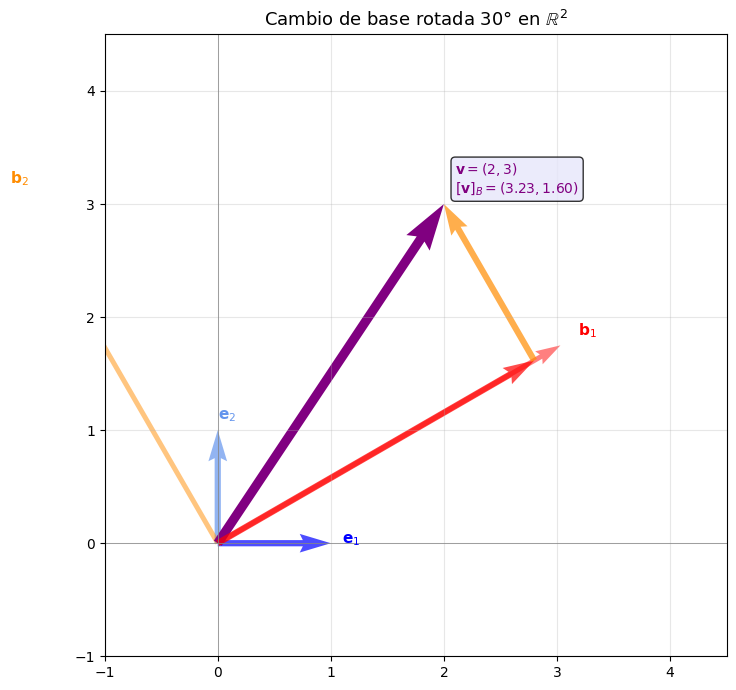

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Ángulo de rotación
theta = np.radians(30)

# Vectores de la base B (rotación 30°)
b1 = np.array([np.cos(theta), np.sin(theta)])
b2 = np.array([-np.sin(theta), np.cos(theta)])
P = np.column_stack([b1, b2])

print("Matriz P (base rotada 30°):")
print(np.round(P, 4))
print(f"\ndet(P) = {np.linalg.det(P):.4f}  (matriz ortogonal: det = 1)")

# Para base ortogonal: P^{-1} = P^T
P_inv = np.linalg.inv(P)
print("\nP^{-1}:")
print(np.round(P_inv, 4))
print("\nP^T (debería ser igual a P^{-1} para base ortogonal):")
print(np.round(P.T, 4))

# Vector v en coordenadas estándar
v = np.array([2., 3.])
v_B = P_inv @ v
print(f"\nv = {v} en base estándar")
print(f"[v]_B = {np.round(v_B, 4)} en base B (rotada 30°)")

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
ax.set_xlim(-1, 4.5); ax.set_ylim(-1, 4.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title('Cambio de base rotada 30° en $\\mathbb{R}^2$', fontsize=13)

# Ejes estándar
for e, lbl, col in [(np.array([1,0]),'$\\mathbf{e}_1$','blue'),(np.array([0,1]),'$\\mathbf{e}_2$','cornflowerblue')]:
    ax.quiver(0,0,e[0],e[1],angles='xy',scale_units='xy',scale=1,color=col,width=0.01,alpha=0.7)
    ax.text(e[0]*1.1,e[1]*1.1,lbl,color=col,fontsize=11)

# Nuevos ejes (base B)
scale = 3.5
for b, lbl, col in [(b1,'$\\mathbf{b}_1$','red'),(b2,'$\\mathbf{b}_2$','darkorange')]:
    ax.quiver(0,0,b[0]*scale,b[1]*scale,angles='xy',scale_units='xy',scale=1,
              color=col,width=0.008,alpha=0.5,linestyle='--')
    ax.text(b[0]*scale*1.05,b[1]*scale*1.05,lbl,color=col,fontsize=11)

# Vector v
ax.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,color='purple',width=0.015)
ax.text(v[0]+0.1,v[1]+0.1,f'$\\mathbf{{v}}=(2,3)$\n$[\\mathbf{{v}}]_B=({v_B[0]:.2f},{v_B[1]:.2f})$',
        fontsize=10, color='purple', bbox=dict(boxstyle='round',facecolor='lavender',alpha=0.8))

# Componentes en base B
comp1 = v_B[0] * b1
ax.quiver(0,0,comp1[0],comp1[1],angles='xy',scale_units='xy',scale=1,
          color='red',width=0.01,alpha=0.7,linestyle=':')
ax.quiver(comp1[0],comp1[1],v[0]-comp1[0],v[1]-comp1[1],angles='xy',scale_units='xy',scale=1,
          color='darkorange',width=0.01,alpha=0.7,linestyle=':')

plt.tight_layout(); plt.show()

## 🟩 Ejemplo 2: Cambio de Base en $\mathbb{R}^3$

Sea la base $\mathcal{B} = \{\mathbf{b}_1, \mathbf{b}_2, \mathbf{b}_3\}$ con:

$$\mathbf{b}_1 = \begin{pmatrix}1\\1\\0\end{pmatrix}, \quad
\mathbf{b}_2 = \begin{pmatrix}0\\1\\1\end{pmatrix}, \quad
\mathbf{b}_3 = \begin{pmatrix}1\\0\\1\end{pmatrix}$$

Dado $\mathbf{v} = (3, 2, 1)^\top$, queremos:

1. Construir $P$ y verificar que $\det(P) \neq 0$.
2. Calcular $P^{-1}$.
3. Encontrar $[\mathbf{v}]_\mathcal{B}$.
4. Verificar que $P \cdot [\mathbf{v}]_\mathcal{B} = \mathbf{v}$.
5. Calcular el cambio de base desde $\mathcal{B}$ a otra base $\mathcal{C}$.

In [2]:
import numpy as np

# Vectores de la base B en R³
b1 = np.array([1., 1., 0.])
b2 = np.array([0., 1., 1.])
b3 = np.array([1., 0., 1.])
P = np.column_stack([b1, b2, b3])

print("Matriz P (3×3):")
print(P)
print(f"det(P) = {np.linalg.det(P):.4f}  → {'invertible ✓' if abs(np.linalg.det(P)) > 1e-10 else 'SINGULAR ✗'}")

P_inv = np.linalg.inv(P)
print("\nP^{-1}:")
print(np.round(P_inv, 4))

# Vector v en coordenadas estándar
v = np.array([3., 2., 1.])
v_B = P_inv @ v
print(f"\nv = {v}")
print(f"[v]_B = {np.round(v_B, 4)}")

# Verificar
v_check = P @ v_B
print(f"\nVerificación P @ [v]_B = {np.round(v_check, 4)}")
print(f"¿Igual a v? {np.allclose(v_check, v)} ✓")

# Interpretación: descomposición de v en la base B
print("\nDescomposición:")
for i, (ci, bi_) in enumerate(zip(v_B, [b1, b2, b3]), 1):
    print(f"  {ci:.4f} × {bi_}")
print(f"  Suma = {np.round(sum(v_B[i-1]*bi_ for i,bi_ in enumerate([b1,b2,b3],1)), 4)}")

# Cambio de base entre B y C
c1 = np.array([1., 0., 1.]); c2 = np.array([0., 1., 0.]); c3 = np.array([0., 0., 1.])
P_C = np.column_stack([c1, c2, c3])
M_B_to_C = np.linalg.inv(P_C) @ P  # Cambio de B a C
print("\nMatriz de cambio de B a C (= P_C^{-1} P_B):")
print(np.round(M_B_to_C, 4))
v_C = np.linalg.inv(P_C) @ v
print(f"\nv en base C: {np.round(v_C, 4)}")

Matriz P (3×3):
[[1. 0. 1.]
 [1. 1. 0.]
 [0. 1. 1.]]
det(P) = 2.0000  → invertible ✓

P^{-1}:
[[ 0.5  0.5 -0.5]
 [-0.5  0.5  0.5]
 [ 0.5 -0.5  0.5]]

v = [3. 2. 1.]
[v]_B = [2. 0. 1.]

Verificación P @ [v]_B = [3. 2. 1.]
¿Igual a v? True ✓

Descomposición:
  2.0000 × [1. 1. 0.]
  0.0000 × [0. 1. 1.]
  1.0000 × [1. 0. 1.]
  Suma = [3. 2. 1.]

Matriz de cambio de B a C (= P_C^{-1} P_B):
[[ 1.  0.  1.]
 [ 1.  1.  0.]
 [-1.  1.  0.]]

v en base C: [ 3.  2. -2.]


## 🟦 Ejemplo 3: La Misma Transformación en Dos Bases

Sea $T: \mathbb{R}^2 \to \mathbb{R}^2$ la transformación de **cizallamiento horizontal**:

$$A = \begin{pmatrix}1 & 2\\ 0 & 1\end{pmatrix}$$

Queremos ver cómo luce esta transformación en la base:

$$\mathcal{B} = \left\{\begin{pmatrix}1\\1\end{pmatrix}, \begin{pmatrix}0\\1\end{pmatrix}\right\}$$

**Procedimiento:**

1. Construir $P$ con los vectores de $\mathcal{B}$.
2. Calcular $A_\mathcal{B} = P^{-1}AP$.
3. Verificar que $A_\mathcal{B}$ actúa igual que $A$, pero *expresada en las coordenadas de $\mathcal{B}$*.
4. Interpretar geométricamente la diferencia.

In [3]:
import numpy as np

# Cizallamiento horizontal
A = np.array([[1., 2.],
              [0., 1.]])

# Base B
b1 = np.array([1., 1.])
b2 = np.array([0., 1.])
P = np.column_stack([b1, b2])
P_inv = np.linalg.inv(P)

# Calcular A en base B
A_B = P_inv @ A @ P

print("Cizallamiento en base estándar A:")
print(A)
print("\nBase B — matriz de cambio P:")
print(P)
print("\nCizallamiento en base B — A_B = P^{-1}AP:")
print(np.round(A_B, 4))

# Verificar: aplicar T a b1 y b2, expresar resultados en base B
print("\n" + "─"*50)
print("Verificación: ¿qué hace T a los vectores de B?")
for i, bi in enumerate([b1, b2], 1):
    Tbi = A @ bi
    Tbi_B = P_inv @ Tbi
    print(f"  T(b{i}) = A @ {bi} = {Tbi}  →  en base B: {np.round(Tbi_B, 4)}")
print("  (Estas son las columnas de A_B ✓)")

Cizallamiento en base estándar A:
[[1. 2.]
 [0. 1.]]

Base B — matriz de cambio P:
[[1. 0.]
 [1. 1.]]

Cizallamiento en base B — A_B = P^{-1}AP:
[[ 3.  2.]
 [-2. -1.]]

──────────────────────────────────────────────────
Verificación: ¿qué hace T a los vectores de B?
  T(b1) = A @ [1. 1.] = [3. 1.]  →  en base B: [ 3. -2.]
  T(b2) = A @ [0. 1.] = [2. 1.]  →  en base B: [ 2. -1.]
  (Estas son las columnas de A_B ✓)


### 📐 Interpretación geométrica del Ejemplo 3

Al calcular $A_\mathcal{B}$, observamos que la representación del cizallamiento *cambia* al cambiar
de base. Pero **la transformación es la misma** — solo la describimos en otro idioma.

Esta es la idea central: $A$ y $A_\mathcal{B}$ son **matrices similares** y representan el mismo operador.

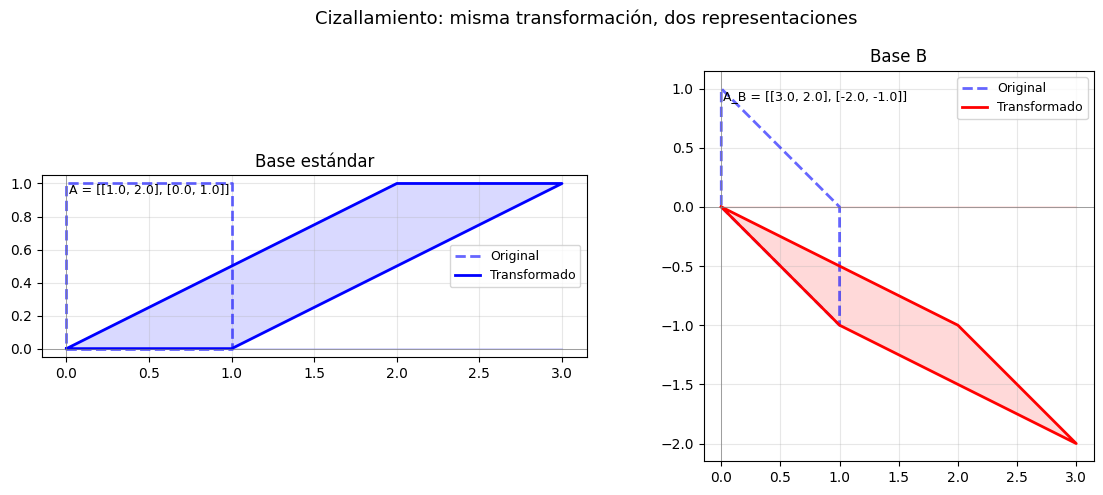

Las áreas de los paralelogramos son iguales: det(A) = 1.00, det(A_B) = 1.00


In [4]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[1., 2.], [0., 1.]])
b1 = np.array([1., 1.]); b2 = np.array([0., 1.])
P = np.column_stack([b1, b2])
A_B = np.linalg.inv(P) @ A @ P

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cizallamiento: misma transformación, dos representaciones', fontsize=13)

# Cuadrado unitario y su imagen bajo T
square = np.array([[0,1,1,0,0],[0,0,1,1,0]], dtype=float)
T_square = A @ square

# En base B
square_B = np.linalg.inv(P) @ square
T_square_B = A_B @ square_B

for ax, orig, transf, title, col in [
    (axes[0], square, T_square, 'Base estándar', 'blue'),
    (axes[1], square_B, T_square_B, 'Base B', 'red')
]:
    ax.plot(orig[0], orig[1], 'b--', lw=2, alpha=0.6, label='Original')
    ax.plot(transf[0], transf[1], color=col, lw=2, label='Transformado')
    ax.fill_between(transf[0], transf[1], alpha=0.15, color=col)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.legend(fontsize=9); ax.set_title(title, fontsize=12)

axes[0].text(0.05, 0.95, f'A = {A.tolist()}', transform=axes[0].transAxes, fontsize=9, verticalalignment='top')
axes[1].text(0.05, 0.95, f'A_B = {np.round(A_B,2).tolist()}', transform=axes[1].transAxes, fontsize=9, verticalalignment='top')
plt.tight_layout(); plt.show()
print("Las áreas de los paralelogramos son iguales:",
      f"det(A) = {np.linalg.det(A):.2f}, det(A_B) = {np.linalg.det(A_B):.2f}")

## 🟨 Ejemplo 4: Base de Autovectores y Diagonalización

Sea la matriz:

$$A = \begin{pmatrix}4 & 1\\ 2 & 3\end{pmatrix}$$

Queremos encontrar la base de autovectores de $A$ y verificar que en esa base,
$A$ tiene una representación diagonal.

**Pasos:**

1. Encontrar los autovalores $\lambda_1, \lambda_2$ resolviendo $\det(A - \lambda I) = 0$.
2. Para cada $\lambda_i$, encontrar el autovector $\mathbf{p}_i$.
3. Construir $P = [\mathbf{p}_1 | \mathbf{p}_2]$.
4. Verificar que $P^{-1}AP = D = \text{diag}(\lambda_1, \lambda_2)$.
5. Verificar $A = PDP^{-1}$ — la **descomposición espectral**.

> 🎓 Esto es una **anticipación del Capítulo 8**. La idea clave: en su propia base, toda
> transformación diagonalizable se convierte en un simple escalado de ejes.

In [5]:
import numpy as np
import sympy as sp

A = np.array([[4., 1.],
              [2., 3.]])

# Encontrar autovalores y autovectores con numpy
eigenvalues, eigenvectors = np.linalg.eig(A)
idx = np.argsort(eigenvalues)  # Ordenar
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Matriz A:")
print(A)
print(f"\nAutovalores: λ₁ = {eigenvalues[0]:.2f}, λ₂ = {eigenvalues[1]:.2f}")
print(f"Autovectores (columnas):\n{np.round(eigenvectors, 4)}")

# Construir P y D
P = eigenvectors
D = np.diag(eigenvalues)
A_B = np.linalg.inv(P) @ A @ P

print("\nMatriz D = P^{-1}AP (debería ser diagonal):")
print(np.round(A_B, 6))

# Verificar: A = P D P^{-1}
A_rec = P @ D @ np.linalg.inv(P)
print(f"\nVerificación A = PDP^{{-1}}: {np.allclose(A_rec, A)}")

# Verificar con sympy (valores exactos)
print("\n--- Verificación exacta con sympy ---")
A_s = sp.Matrix([[4,1],[2,3]])
print("Polinomio característico:", sp.factor(A_s.charpoly().as_expr()))
print("Autovalores:", A_s.eigenvals())

Matriz A:
[[4. 1.]
 [2. 3.]]

Autovalores: λ₁ = 2.00, λ₂ = 5.00
Autovectores (columnas):
[[-0.4472  0.7071]
 [ 0.8944  0.7071]]

Matriz D = P^{-1}AP (debería ser diagonal):
[[ 2.  0.]
 [-0.  5.]]

Verificación A = PDP^{-1}: True

--- Verificación exacta con sympy ---
Polinomio característico: (lambda - 5)*(lambda - 2)
Autovalores: {5: 1, 2: 1}


### 🔎 ¿Por qué la base de autovectores es la mejor?

En la base de autovectores, la transformación $T$ **no mezcla las coordenadas**.
Si $[\mathbf{v}]_\mathcal{B} = (c_1, c_2)^\top$ en la base de autovectores:

$$T(\mathbf{v}) = D \cdot [\mathbf{v}]_\mathcal{B} = \begin{pmatrix}\lambda_1 & 0\\ 0 & \lambda_2\end{pmatrix}\begin{pmatrix}c_1\\c_2\end{pmatrix} = \begin{pmatrix}\lambda_1 c_1\\ \lambda_2 c_2\end{pmatrix}$$

¡Cada coordenada se escala independientemente! Esto simplifica enormemente potencias de matrices,
sistemas de ecuaciones diferenciales, y muchos problemas de aplicación.

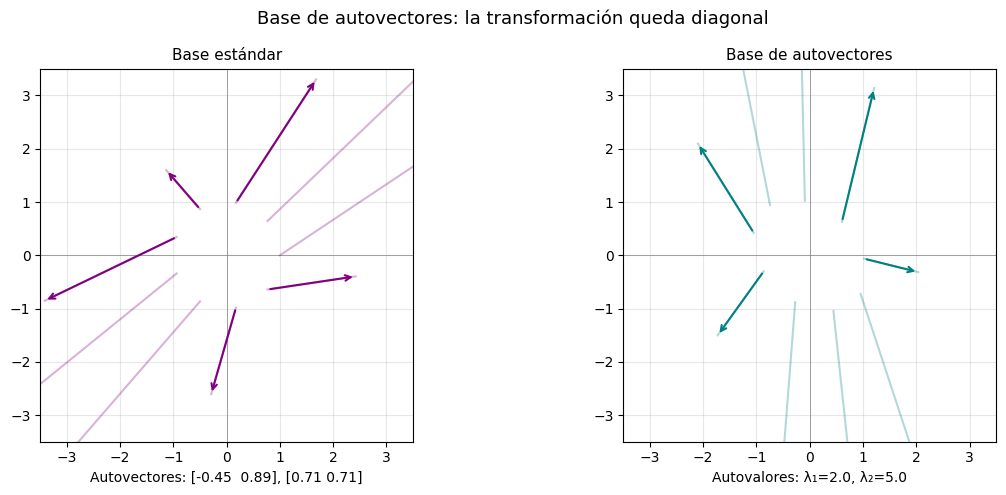

Conclusión: en base de autovectores, T escala el eje 1 por λ₁=2.0
            y el eje 2 por λ₂=5.0 — sin mezcla entre coordenadas.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[4., 1.], [2., 3.]])
eigenvalues, eigenvectors = np.linalg.eig(A)
idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]; eigenvectors = eigenvectors[:, idx]
P = eigenvectors
D = np.diag(eigenvalues)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Base de autovectores: la transformación queda diagonal', fontsize=13)

# Varios vectores
angles = np.linspace(0, 2*np.pi, 9, endpoint=False)
vecs = np.array([np.cos(angles), np.sin(angles)])
Av = A @ vecs

# En base de autovectores
vecs_B = np.linalg.inv(P) @ vecs
Av_B = D @ vecs_B

for ax, vs, Tvs, title, col in [
    (axes[0], vecs, Av, 'Base estándar', 'purple'),
    (axes[1], vecs_B, Av_B, 'Base de autovectores', 'teal')
]:
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(title, fontsize=11)
    for i in range(vs.shape[1]):
        ax.annotate('', xy=(Tvs[0,i], Tvs[1,i]), xytext=(vs[0,i], vs[1,i]),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
        ax.plot([vs[0,i], Tvs[0,i]], [vs[1,i], Tvs[1,i]], col, alpha=0.3)

axes[0].set_xlabel(f'Autovectores: {np.round(eigenvectors[:,0],2)}, {np.round(eigenvectors[:,1],2)}')
axes[1].set_xlabel(f'Autovalores: λ₁={eigenvalues[0]:.1f}, λ₂={eigenvalues[1]:.1f}')
plt.tight_layout(); plt.show()
print(f"Conclusión: en base de autovectores, T escala el eje 1 por λ₁={eigenvalues[0]:.1f}")
print(f"            y el eje 2 por λ₂={eigenvalues[1]:.1f} — sin mezcla entre coordenadas.")